<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/CustomerChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading the Dataset**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data=pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

## **Understanding the dataset**

In [13]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,151.65


In [ ]:
data.shape

In [ ]:
data.info()

In [ ]:
data.describe()

In [ ]:
data.isnull().sum()

In [ ]:
print(type("TotalChargers"))

In [ ]:
data.duplicated().sum()

In [ ]:
data['Churn'].value_counts()

In [ ]:
data['Churn'].value_counts(normalize=True)

In [ ]:
print(data['gender'].value_counts())
print(data['SeniorCitizen'].value_counts())
print(data['Partner'].value_counts())
print(data['Dependents'].value_counts())
print(data['PhoneService'].value_counts())
print(data['MultipleLines'].value_counts())
print(data['InternetService'].value_counts())
print(data['OnlineSecurity'].value_counts())
print(data['OnlineBackup'].value_counts())
print(data['DeviceProtection'].value_counts())
print(data['TechSupport'].value_counts())
print(data['StreamingTV'].value_counts())
print(data['StreamingMovies'].value_counts())
print(data['Contract'].value_counts())
print(data['PaperlessBilling'].value_counts())
print(data['PaymentMethod'].value_counts())

In [5]:
# 1. Convert TotalCharges to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# 2. Check missing values after conversion
missing_total_charges = data['TotalCharges'].isnull().sum()
print(f"Missing values in TotalCharges after conversion: {missing_total_charges}")

# 3. Check for duplicate rows (optional)
duplicate_rows = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")


Missing values in TotalCharges after conversion: 11
Number of duplicate rows: 0


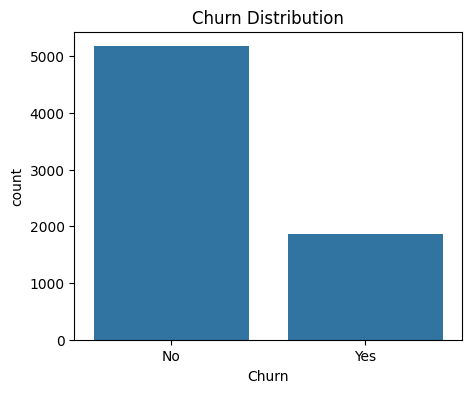

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=data)
plt.title("Churn Distribution")
plt.show()

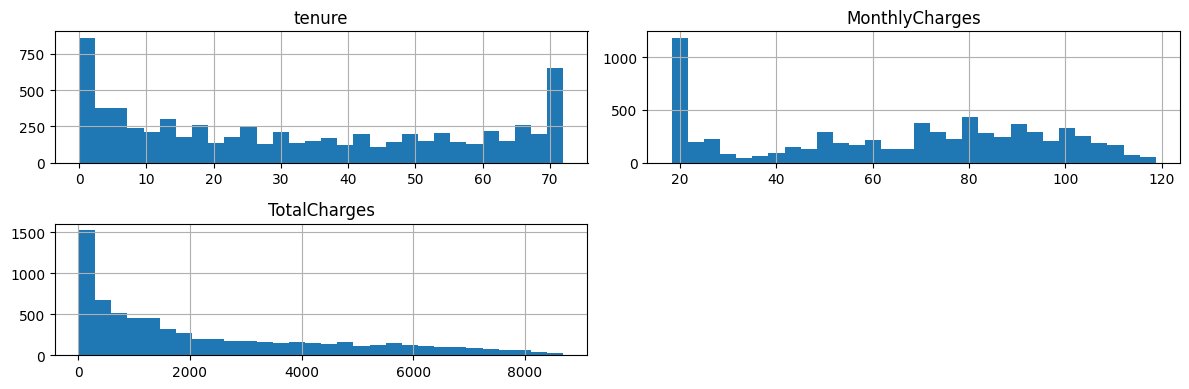

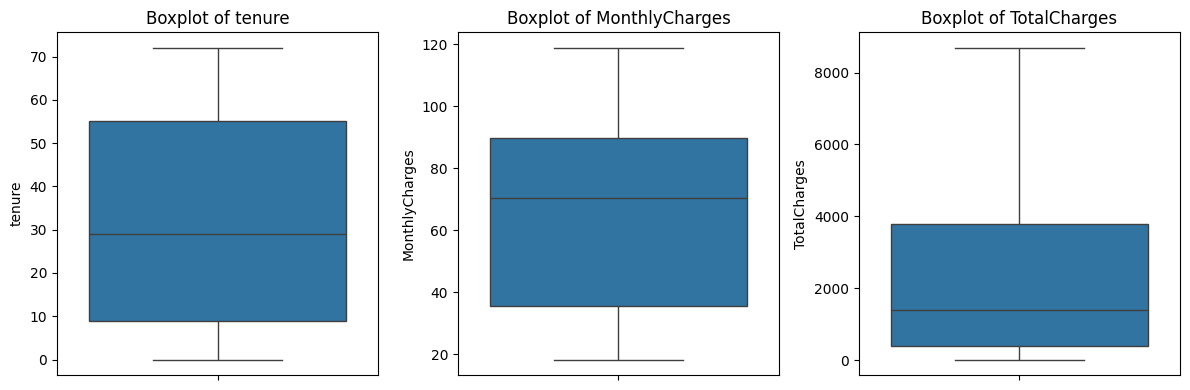

In [7]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']

# Histograms
data[num_cols].hist(figsize=(12,4), bins=30)
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(12,4))
for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

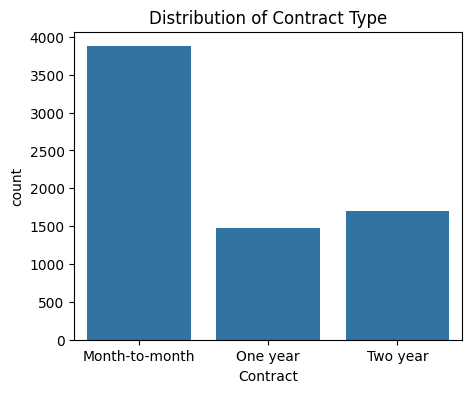

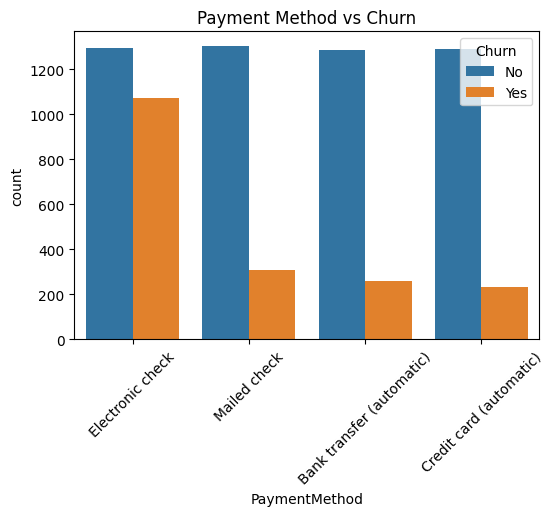

In [8]:
# ---------------------------
# 1.3.3 Key Categorical Variable Distribution
# ---------------------------
# Optional: Contract or InternetService distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Contract', data=data)
plt.title("Distribution of Contract Type")
plt.show()

# PaymentMethod vs Churn (important insight)
plt.figure(figsize=(6,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=data)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

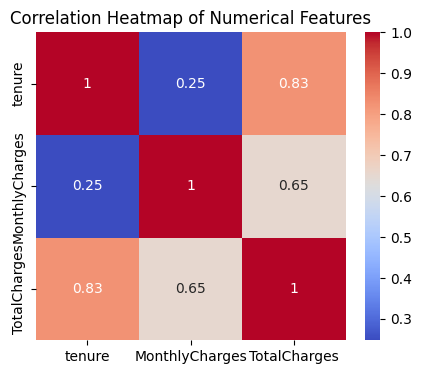

In [10]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(5,4))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()